# Modelling a circumbinary dust rim with HMC

This tutorial walks through parametric modelling of a circumbinary dust rim using
a chromatic model with an azmiuthally modulated Gaussian rim. For this we'll be using
the VLTI/PIONIER dataset of [Hillen et al. 2016](http://dx.doi.org/10.1051/0004-6361/201628125),
where they target the circumbinary disk surrounding the evolved post-AGB binary 
IRAS 08544-443.

First, let's import everything we will need.

In [1]:
# import pyoifits as oifits
from pathlib import Path

import anesthetic
import blackjax
import ehtplot  # type: ignore # noqa: F401
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pyoifits as oifits
import tqdm
from blackjax.ns.utils import finalise
from jax.tree_util import Partial
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable

from drpangloss._utils import dict_merge_az_amp_and_az_pa
from drpangloss.models import BinaryGaussianRimModel, OIData, loglike

## Loading data

The dataset consists of multiple OIFITS files. We'll be reading these in and
combining them into one consistent dataset, for which `pyoifits` provides a convenient
interface via the `+` addition operator. This `pyoifits` object can then readily
be wrapped into a `OIData` object which `drpangloss` uses to handle data. The PIONIER
data consists of squared visibilities ($V^2$) and closure phases ($\phi3$) for six
different wavelength channels. 

In [2]:
ddir = Path("/home/toond/Documents/phd/paper_iras08_time_series/data/ep1/")

data_pyoifits = None
for oifits_file in ddir.glob("*.fits"):
    print(f"CONSIDERING FILE: {oifits_file}")
    if data_pyoifits is None:
        data_pyoifits = oifits.open(oifits_file, memmap=False)
    else:
        data_pyoifits += oifits.open(oifits_file, memmap=False)

# Create a OIData object from the resulting pyofits object.
oidata = OIData(data_pyoifits)

CONSIDERING FILE: /home/toond/Documents/phd/paper_iras08_time_series/data/ep1/PIONI.2015-01-22T03:55:02.519_oidataCalibrated.fits
CONSIDERING FILE: /home/toond/Documents/phd/paper_iras08_time_series/data/ep1/PIONI.2015-01-22T09:35:42.873_oidataCalibrated.fits
CONSIDERING FILE: /home/toond/Documents/phd/paper_iras08_time_series/data/ep1/PIONI.2015-01-25T07:03:21.442_oidataCalibrated.fits
CONSIDERING FILE: /home/toond/Documents/phd/paper_iras08_time_series/data/ep1/PIONI.2015-02-24T07:00:35.226_oidataCalibrated.fits
CONSIDERING FILE: /home/toond/Documents/phd/paper_iras08_time_series/data/ep1/PIONI.2015-01-25T09:05:31.041_oidataCalibrated.fits
CONSIDERING FILE: /home/toond/Documents/phd/paper_iras08_time_series/data/ep1/PIONI.2015-01-22T07:50:01.669_oidataCalibrated.fits
CONSIDERING FILE: /home/toond/Documents/phd/paper_iras08_time_series/data/ep1/PIONI.2015-01-22T05:06:30.358_oidataCalibrated.fits
CONSIDERING FILE: /home/toond/Documents/phd/paper_iras08_time_series/data/ep1/PIONI.2015-0

### Plotting to check the loaded data.

Below, we extract some useful quantities to make some diagnostic plots of our data,
just to see if all data has been read in properly and if we can alreay glean something
about the target structure from the data. To have a good look at the spatial and 
chromatic structure of the target, we'll be plotting the $V^2$ data and $\phi3$ data
as a function of observed spatial frequency (using the longest baseline per closure
triangle for the $\phi3$ data), and color-coding everything by wavelength $\lambda$.

In [3]:
print(oidata.phi.size)
print(oidata.vis.size)

480
792


In [4]:
oidata.vis

Array([0.48305708, 0.47116333, 0.41601545, 0.3875169 , 0.36071092,
       0.3327431 , 0.535     , 0.5033673 , 0.46359614, 0.39582393,
       0.34180158, 0.31260818, 0.42849287, 0.36693716, 0.3321177 ,
       0.29430366, 0.26026568, 0.22492252, 0.5061389 , 0.47298682,
       0.40671644, 0.36626458, 0.3154397 , 0.27968   , 0.50386304,
       0.46809012, 0.42018276, 0.37138122, 0.33003667, 0.30358657,
       0.4865985 , 0.4672157 , 0.43011448, 0.3841998 , 0.36740363,
       0.35172853, 0.44014472, 0.43248513, 0.39287305, 0.3647024 ,
       0.3312467 , 0.3064672 , 0.44438285, 0.41447073, 0.3779132 ,
       0.34736207, 0.30241367, 0.28678572, 0.37555036, 0.34917983,
       0.32940057, 0.29908594, 0.26543164, 0.2511158 , 0.43995386,
       0.41589215, 0.37258503, 0.33084166, 0.28981912, 0.25784206,
       0.4293481 , 0.3987076 , 0.37027213, 0.32566145, 0.2816837 ,
       0.24578862, 0.40482005, 0.38008234, 0.3417941 , 0.31567764,
       0.2802736 , 0.26462692, 0.5028013 , 0.47180796, 0.43383

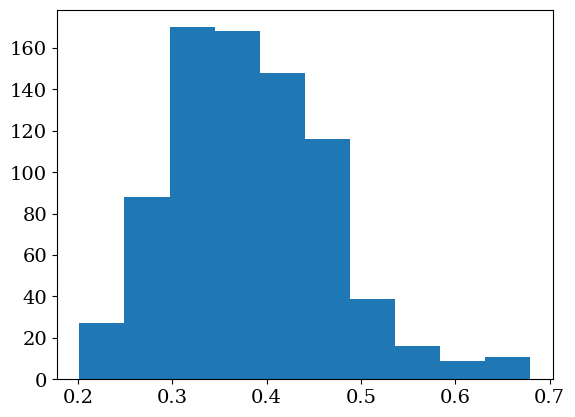

In [5]:
fig, ax = plt.subplots(1, 1)
ax.hist(oidata.vis)
plt.show()

In [6]:
# Observed squared visibilities data per observed spatial freuqency.
obs_vis2 = oidata.vis
obs_d_vis2 = oidata.d_vis
obs_vis2_wavel = oidata.wavel  # Wavelength per observed squared visibility.
# Spatial frequencies per baseline.
obs_uf = oidata.u / oidata.wavel
obs_vf = oidata.v / oidata.wavel
obs_base = jnp.hypot(oidata.u, oidata.v)
obs_basef = jnp.hypot(obs_uf, obs_vf)  # Norm of spatial frequency.

# Observed closure phases per closure triangle in frequency space.
obs_cp = oidata.phi
obs_d_cp = oidata.d_phi
obs_cp_wavel = obs_vis2_wavel[
    oidata.i_cps1
]  # Wavelength per observed closure phase.

# Get max baseline norm for the baseline closure triangles.
obs_base1 = obs_base[oidata.i_cps1]
obs_base2 = obs_base[oidata.i_cps2]
obs_base3 = obs_base[oidata.i_cps3]
obs_basemaxf = jnp.maximum(
    obs_base1 / obs_cp_wavel,
    jnp.maximum(obs_base2 / obs_cp_wavel, obs_base3 / obs_cp_wavel),
)

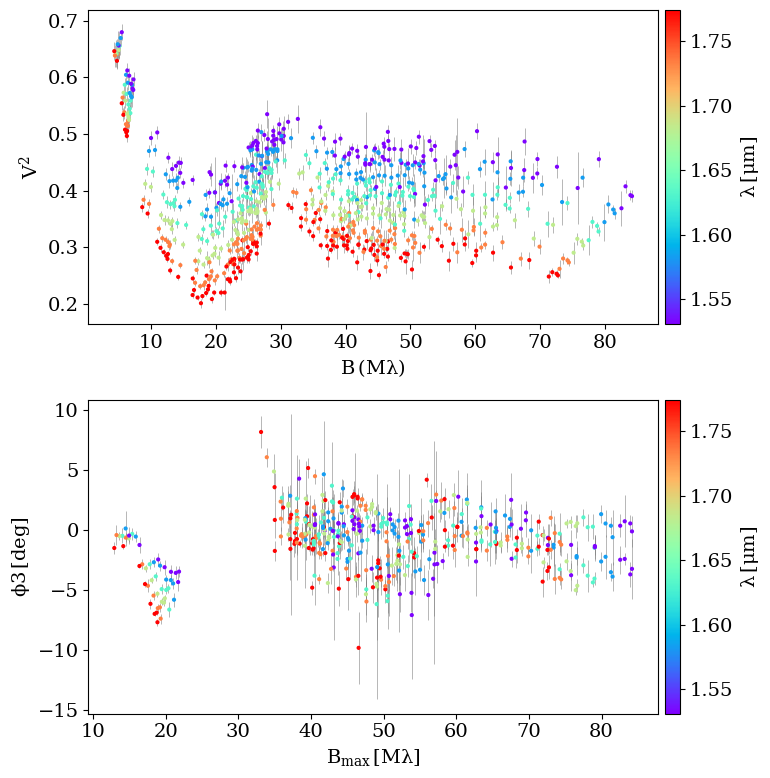

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Squared visibility data.
axes[0].errorbar(
    obs_basef / 1e6,
    obs_vis2,
    obs_d_vis2,
    fmt=",",
    elinewidth=0.4,
    ecolor="grey",
    zorder=-1,
)
sc1 = axes[0].scatter(
    obs_basef / 1e6, obs_vis2, c=obs_vis2_wavel * 1e6, s=4, cmap="rainbow"
)

# Closure phase data.
axes[1].errorbar(
    obs_basemaxf / 1e6,
    obs_cp,
    obs_d_cp,
    fmt=",",
    elinewidth=0.4,
    ecolor="grey",
    zorder=-1,
)
sc2 = axes[1].scatter(
    obs_basemaxf / 1e6, obs_cp, c=obs_cp_wavel * 1e6, s=4, cmap="rainbow"
)

fig.colorbar(
    sc1, ax=axes[0], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
)
fig.colorbar(
    sc2, ax=axes[1], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
)

# axes[0].set_xlim(0)
# axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel(r"$V^2$")
axes[0].set_xlabel(r"$B \, (\mathregular{M\lambda})$")

# axes[1].set_xlim(0)
axes[1].set_ylabel(r"$\phi 3 \, [\mathregular{deg}]$")
axes[1].set_xlabel(r"$B_{\mathregular{max}} \, [\mathregular{M\lambda}]$")

plt.tight_layout()
plt.show()

We can also hack together a plot where the visibilities are displayed as line per 
baseline. This way we can more clearly see trend for the same baseline but across
 wavelengths.

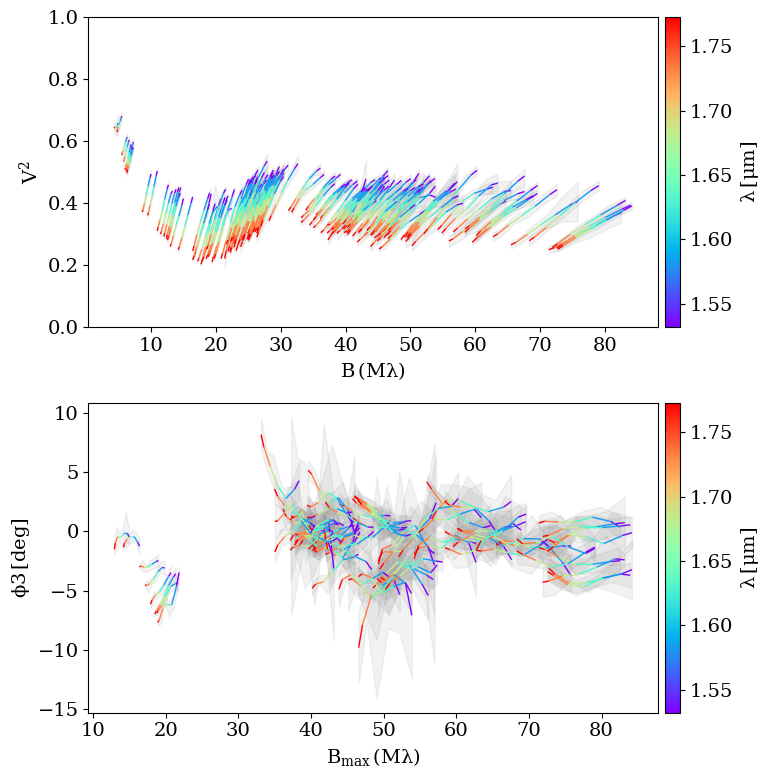

In [8]:
# Split the total data 1D arrays into a list of of arrays based on where the
# baseline coordinate changes.
split_indices_vis2 = jnp.where(jnp.diff(oidata.u) != 0)[0] + 1
obs_basef_split = jnp.split(obs_basef, split_indices_vis2)
obs_vis2_split = jnp.split(obs_vis2, split_indices_vis2)
obs_d_vis2_split = jnp.split(obs_d_vis2, split_indices_vis2)
obs_vis2_wavel_split = jnp.split(obs_vis2_wavel, split_indices_vis2)

split_indices_base1 = jnp.where(jnp.diff(obs_base1) != 0)[0] + 1
split_indices_base2 = jnp.where(jnp.diff(obs_base2) != 0)[0] + 1
split_indices_base3 = jnp.where(jnp.diff(obs_base3) != 0)[0] + 1
split_indices_cp = jnp.unique(
    jnp.concatenate(
        (
            split_indices_base1,
            split_indices_base2,
            split_indices_base3,
        )
    )
)
obs_basemaxf_split = jnp.split(obs_basemaxf, split_indices_cp)
obs_cp_split = jnp.split(obs_cp, split_indices_cp)
obs_d_cp_split = jnp.split(obs_d_cp, split_indices_cp)
obs_cp_wavel_split = jnp.split(obs_cp_wavel, split_indices_cp)


# Quick function to get line segments create a matplotlib LineCollection for display.
def _get_line_collection_segments(x, y):
    # Reshape data into shape (num_segments, 2, 2) for LineCollection, using the
    # geometric mean points so colours switch halfway along the line segments.
    x_mids = (x[:-1] + x[1:]) / 2
    y_mids = (y[:-1] + y[1:]) / 2
    x_segments = jnp.concatenate(
        (
            jnp.array([x[0]]),
            x_mids,
            jnp.array([x[-1]]),
        )
    )
    y_segments = jnp.concatenate(
        (
            jnp.array([y[0]]),
            y_mids,
            jnp.array([y[-1]]),
        )
    )

    points = jnp.array([x_segments, y_segments]).T.reshape(-1, 1, 2)
    segments = jnp.concatenate([points[:-1], points[1:]], axis=1)

    return segments


# Plot per baseline/triangle.
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
for i, el in enumerate(obs_vis2_split):
    # Get quantities for this baseline.
    obs_basef_i, obs_vis2_i, obs_d_vis2_i, obs_vis2_wavel_i = (
        obs_basef_split[i] / 1e6,
        obs_vis2_split[i],
        obs_d_vis2_split[i],
        obs_vis2_wavel_split[i],
    )
    # Fill the error region between the lower and upper bounds
    axes[0].fill_between(
        obs_basef_i,
        obs_vis2_i + obs_d_vis2_i,
        obs_vis2_i - obs_d_vis2_i,
        color="grey",
        alpha=0.1,
    )
    # Create a LineCollection object to interpolate the color along the plotted lines.
    lc = LineCollection(
        _get_line_collection_segments(obs_basef_i, obs_vis2_i), cmap="rainbow"
    )
    lc.set_array(
        obs_vis2_wavel_i * 1e6
    )  # Map the wavelength values to segments.
    lc.set_linewidth(1.0)
    axes[0].add_collection(lc)

for i, el in enumerate(obs_cp_split):
    # Get quantities for this baseline.
    obs_basemaxf_i, obs_cp_i, obs_d_cp_i, obs_cp_wavel_i = (
        obs_basemaxf_split[i] / 1e6,
        obs_cp_split[i],
        obs_d_cp_split[i],
        obs_cp_wavel_split[i],
    )
    # Fill the error region between the lower and upper bounds
    axes[1].fill_between(
        obs_basemaxf_i,
        obs_cp_i + obs_d_cp_i,
        obs_cp_i - obs_d_cp_i,
        color="grey",
        alpha=0.1,
    )
    # Create a LineCollection object to interpolate the color along the plotted lines.
    lc = LineCollection(
        _get_line_collection_segments(obs_basemaxf_i, obs_cp_i), cmap="rainbow"
    )
    lc.set_array(
        obs_cp_wavel_i * 1e6
    )  # Map the wavelength values to segments.
    lc.set_linewidth(1.0)
    axes[1].add_collection(lc)


# axes[0].autoscale()
# axes[0].set_xlim(0)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel(r"$V^2$")
axes[0].set_xlabel(r"$B \, (\mathregular{M\lambda})$")
cbar = fig.colorbar(
    lc, ax=axes[0], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
)

# axes[1].set_xlim(0)
axes[1].set_ylabel(r"$\phi 3 \, [\mathregular{deg}]$")
axes[1].set_xlabel(r"$B_{\mathregular{max}} \, (\mathregular{M\lambda})$")
cbar = fig.colorbar(
    lc, ax=axes[1], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
)

plt.tight_layout()
plt.show()

As we can see, the visibilities show some Bessel-like oscillations around a $V^2$ plateau.
This is indicative of some ring-like structure surrounding a central un- or marginally-resolved
object (which in this case is the primary star). There is also clearly a chromatic effect
where the level of the plateau strongly decreases at longer wavelengths, indicating that at these
wavelengths the total flux of the central star contributes less. The $\phi3$ data are a bit
harder to interpret per triangle, but are clearly non-zero, which indicates some asymmetry 
in the intensity of the distribution. This is a combination of the presence of the binary 
companion, an offset of the central star relative to the disk rim, or azimuthal 
modulations of the disk rim itself! We'll model all these effects below.


## Defining a chromatic circumbinary disk model

Below, we'll recreate the [Hillen et al. 2016](http://dx.doi.org/10.1051/0004-6361/201628125) model
used for the system. There are some differences though, including the use of spectral indices 
($d$ if $F_{\lambda} \propto (\lambda / \lambda_0)^d$) instead of blackbody temperatures 
to define the spectral behaviour. We also do not fit any chromaticity to the overresolved
background and secondary star.

The model consists of a chromatic point source for the primary, a chromatic azimuthally
modulated Gaussian disk rim and a grey companion point source and overresolved flux.
This model is implemented in the `BinaryGaussianRimModel` class.
Feel free to play around a little with the parameters and see how things change.

In [9]:
# Recreation of the Hillen et al. 2016 (A&A 588, L1) model. Differences include that the
# primary star is not in Rayleigh-Jeans regime (instead `si_p` is taken from a power-law
# fit to the synthetic H-band SED fit spectrum). `si_rim` (derived from the blackbody
# temperature found in the paper) has been corrected accordingly.
model_params = {
    "flux_p": 0.597,  # Total flux fraction of the primary.
    "dra_p": 0.0,  # Primary right ascension offset in milliarcseconds.
    "ddec_p": 0.0,  # Primary declination offset in milliarcseconds.
    "si_p": -3.166,  # Spectral index of the primary.
    "flux_s": 0.039,  # Secondary flux fraction.
    "dra_s": -0.5,  # Secondary right ascension offset in milliarcseconds.
    "ddec_s": -0.7,  # Secondary declination offset in milliarcseconds.
    "diam_rim": 14.15,  # Diameter of the rim in milliarcseconds.
    "fwhm_rim": 3.233,  # Gaussian FWHM of the rim in milliarcseconds.
    "inc_rim": 19.0,  # Inclination of the rim in degrees.
    "pa_rim": 6.0,  # Position angle of the rim in degrees.
    "si_rim": 3.6,  # Rim spectral indexobs_vis2_i (from paper T_bb & modified for 'si_p' value).
    "flux_bkg": 0.155,  # Overresolved background flux fraction.
    "az_amps": [
        0.43011627,
        0.2745906,
    ],  # 1st & 2nd rim azimuthal modulation amplitudes (the paper worked with equivalent coefficients).
    "az_pas": [
        35.537678 + 6.0,
        50.245735 + 6.0,
    ],  # 1st & 2nd rim azimuthal modulation offset angles relative to 'pa_rim' in degrees.
    "wave0": 1.65e-6,  # Wavelength at which the flux fractions are defined in meter (not a free parameter).
}

model = BinaryGaussianRimModel(**model_params)

### Visualising the model morphology

The model also includes a model function to calculate an image of the modelled Gaussian 
rim. Note that this is purely for display and visual inspection purposes though. For this
model, the image is not actually used to calculate the predicted model observables (which
in this case are fully analytical).

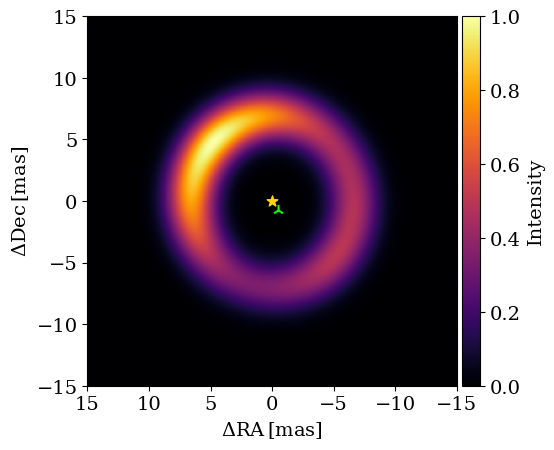

In [10]:
npix = 300  # Number of pixels along the field-of-view.
ps = 0.1  # Pixelscale in milliarcseconds.
fov = npix * ps

# Get an image of the rim (normalized so sum of pixels is one).
rim_img = model.get_img(npix=npix, ps=ps)

fig, ax = plt.subplots(1, 1)
# Plot image.
im = ax.imshow(
    rim_img / jnp.max(rim_img),
    extent=(
        fov / 2,
        -fov / 2,
        -fov / 2,
        fov / 2,
    ),
    cmap="inferno",
)
# Add stars
ax.scatter(model.dra_p, model.ddec_p, marker="*", s=64, color="gold")
ax.scatter(model.dra_s, model.ddec_s, marker="2", s=64, color="lime")


# Add colorbar to the side.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label="Intensity")

ax.set_xlabel(r"$\Delta \mathregular{RA} \, \mathregular{[mas]}$")
ax.set_ylabel(r"$\Delta \mathregular{Dec} \, \mathregular{[mas]}$")

plt.show()

### Visualising the predicted model observables

Let's see what our current model predicts for the $V^2$ and $\phi3$ observables, and how
it holds up against the observed data. You'll see that we're not quite there yet
in terms of having a good fit to the data.

In [11]:
def plot_observable_predicitons_model(oidata, model):
    # Model predictions.
    oi_pred = oidata.model(model)
    mod_vis2 = oi_pred[: jnp.size(oidata.vis)]
    mod_cp = oi_pred[jnp.size(oidata.vis) :]

    # Observed squared visibilities data per observed spatial freuqency.
    obs_vis2 = oidata.vis
    obs_d_vis2 = oidata.d_vis
    obs_vis2_wavel = (
        oidata.wavel
    )  # Wavelength per observed squared visibility.
    # Spatial frequencies per baseline.
    obs_uf = oidata.u / oidata.wavel
    obs_vf = oidata.v / oidata.wavel
    obs_base = jnp.hypot(oidata.u, oidata.v)
    obs_basef = jnp.hypot(obs_uf, obs_vf)  # Norm of spatial frequency.

    # Observed closure phases per closure triangle in frequency space.
    obs_cp = oidata.phi
    obs_d_cp = oidata.d_phi
    obs_cp_wavel = obs_vis2_wavel[
        oidata.i_cps1
    ]  # Wavelength per observed closure phase.

    # Get max baseline norm for the baseline closure triangles.
    obs_base1 = obs_base[oidata.i_cps1]
    obs_base2 = obs_base[oidata.i_cps2]
    obs_base3 = obs_base[oidata.i_cps3]
    obs_basemaxf = jnp.maximum(
        obs_base1 / obs_cp_wavel,
        jnp.maximum(obs_base2 / obs_cp_wavel, obs_base3 / obs_cp_wavel),
    )

    fig, axes = plt.subplots(2, 1, figsize=(8, 8))

    # Squared visibility data.
    axes[0].errorbar(
        obs_basef / 1e6,
        obs_vis2,
        obs_d_vis2,
        fmt=",",
        elinewidth=0.4,
        ecolor="grey",
        zorder=-1,
    )
    sc1 = axes[0].scatter(
        obs_basef / 1e6, obs_vis2, c=obs_vis2_wavel * 1e6, s=4, cmap="rainbow"
    )
    axes[0].scatter(
        obs_basef / 1e6, mod_vis2, c="k", s=4, zorder=-1, marker="."
    )

    # Closure phase data.
    axes[1].errorbar(
        obs_basemaxf / 1e6,
        obs_cp,
        obs_d_cp,
        fmt=",",
        elinewidth=0.4,
        ecolor="grey",
        zorder=-1,
    )
    sc2 = axes[1].scatter(
        obs_basemaxf / 1e6, obs_cp, c=obs_cp_wavel * 1e6, s=4, cmap="rainbow"
    )
    axes[1].scatter(
        obs_basemaxf / 1e6, mod_cp, c="k", s=4, zorder=-1, marker="."
    )

    fig.colorbar(
        sc1, ax=axes[0], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
    )
    fig.colorbar(
        sc2, ax=axes[1], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
    )

    axes[0].set_ylabel(r"$V^2$")
    axes[0].set_xlabel(r"$B \, (\mathregular{M\lambda})$")

    axes[1].set_ylabel(r"$\phi 3 \, [\mathregular{deg}]$")
    axes[1].set_xlabel(r"$B_{\mathregular{max}} \, [\mathregular{M\lambda}]$")

    plt.tight_layout()
    plt.show()


def get_mean_chi2_model(oidata, model):
    # Model predictions.
    oi_pred = oidata.model(model)
    mod_vis = oi_pred[: jnp.size(oidata.vis)]
    mod_phi = oi_pred[jnp.size(oidata.vis) :]

    # Get chi2s
    nvis, nphi = oidata.vis.size, oidata.phi.size
    ntot = nvis + nphi
    chi2_vis = jnp.sum((oidata.vis - mod_vis) ** 2 / oidata.d_vis**2)
    chi2_phi = jnp.sum((oidata.phi - mod_phi) ** 2 / oidata.d_phi**2)
    chi2_tot = chi2_vis + chi2_phi

    chi2m_vis, chi2m_phi, chi2m_tot = (
        chi2_vis / nvis,
        chi2_phi / nphi,
        chi2_tot / ntot,
    )

    return chi2m_tot, chi2m_vis, chi2m_phi

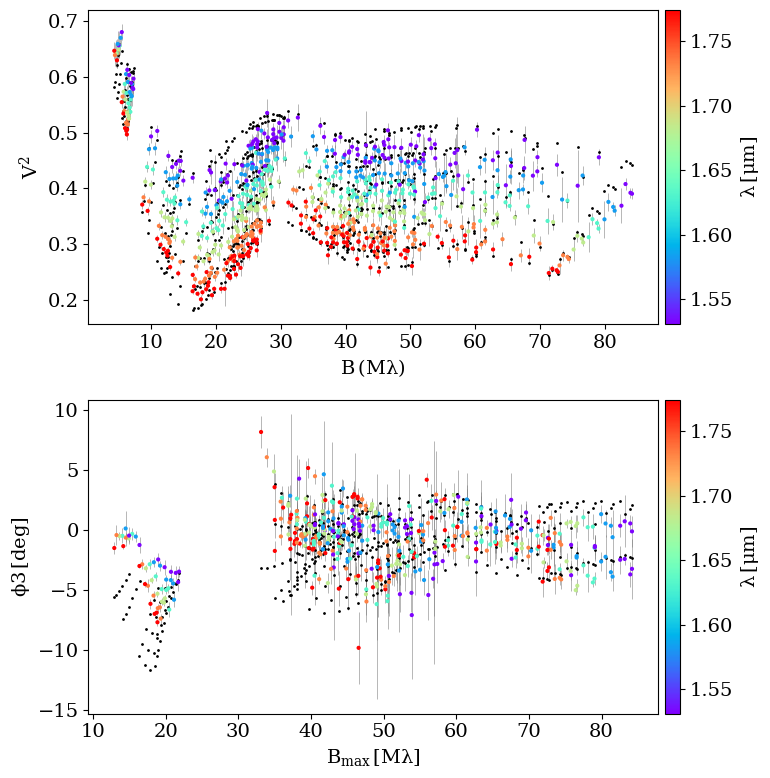

In [12]:
plot_observable_predicitons_model(oidata, model)

## Inference using nested sampling

`Blackjax` sampler APIs typically expect log-likelihood and prior functions which just
take in a vector of parameter values, passed as a 1D JAX array. Since we're dealing
with both free and fixed parameters for our models (e.g. the central wavelength `wave0`),
this requires us to do some more manual work. The azimuthal modulation amplitudes and
position angles, for example, are defined in the model as single arrays `az_amps` and
`az_pas` (for computational reasons). As a result, we'll treat each modulation as 
a separate parameter in our top-level code, but we'll have to concatenate them back
into these single arrays inside our data log-likelihood function.

Using a more extensive probabilistic programming framework like `numpyro` to do our 
sampling would make this a lot less involved. Nevertheless, we wouldn't have access
to the nested sampling algorithm we wish to showcase here, which is useful for 
exploration of potentially multimodal posterior landscapes, where `numpyro`'s HMC-based
algorithms could easily get stuck.


In [13]:
model_params = {
    "flux_p": 0.597,  # Total flux fraction of the primary.
    "dra_p": 0.0,  # Primary right ascension offset in milliarcseconds.
    "ddec_p": 0.0,  # Primary declination offset in milliarcseconds.
    "si_p": -3.166,  # Spectral index of the primary.
    "flux_s": 0.039,  # Secondary flux fraction.
    "dra_s": -0.5,  # Secondary right ascension offset in milliarcseconds.
    "ddec_s": -0.7,  # Secondary declination offset in milliarcseconds.
    "diam_rim": 14.15,  # Diameter of the rim in milliarcseconds.
    "fwhm_rim": 3.233,  # Gaussian FWHM of the rim in milliarcseconds.
    "inc_rim": 19.0,  # Inclination of the rim in degrees.
    "pa_rim": 6.0,  # Position angle of the rim in degrees.
    "si_rim": 3.6,  # Rim spectral index (from paper T_bb & modified for 'si_p' value).
    "flux_bkg": 0.155,  # Overresolved background flux fraction.
    "az_amps": [
        0.43011627,
        0.2745906,
    ],  # 1st & 2nd rim azimuthal modulation amplitudes (the paper worked with equivalent coefficients).
    "az_pas": [
        35.537678 + 6.0,
        50.245735 + 6.0,
    ],  # 1st & 2nd rim azimuthal modulation offset angles relative to 'pa_rim' in degrees.
    "wave0": 1.65e-6,  # Wavelength at which the flux fractions are defined in meter (not a free parameter).
}

In [14]:
# Fixed parameter values. Note that due to the layout of the internal calculations, all
# azimuthal modulations must be either free, or all fixed.
param_dict_fixed = {
    "si_p": -3.166,
    "pa_rim": 6.0,
    "az_amp1": 0.43011627,
    "az_amp2": 0.2745906,
    "az_pa1": 35.537678 + 6.0,
    "az_pa2": 50.245735 + 6.0,
    "wave0": 1.65e-6,
}

param_range_dict = {
    "flux_p": (0.55, 0.65),
    "dra_p": (-3.0, 3.0),
    "ddec_p": (-3.0, 3.0),
    "flux_s": (0.01, 0.07),
    "dra_s": (-3.0, 3.0),
    "ddec_s": (-3.0, 3.0),
    "diam_rim": (11.0, 16.0),  # Diameter of the rim in milliarcseconds.
    "fwhm_rim": (1.0, 4.0),  # Gaussian FWHM of the rim in milliarcseconds.
    "inc_rim": (0.0, 30.0),
    "si_rim": (0.0, 5.0),
    "flux_bkg": (0.0, 20.0),
}

# # Uniform prior range dictionary for free parameters.
# param_range_dict = {
#     "flux_p": (0.50, 0.70),
#     "dra_p": (-3.0, 3.0),
#     "ddec_p": (-3.0, 3.0),
#     "flux_s": (0.01, 0.08),
#     "dra_s": (-3.0, 3.0),
#     "ddec_s": (-3.0, 3.0),
#     "diam_rim": (11.0, 15.0),
#     "fwhm_rim": (1.0, 5.0),
#     "si_rim": (-2.5, 4.0),
#     "az_amp1": (0.0, 1.0),  # Modulations params are now split up.
#     "az_pa1": (-180.0, 180.0),
# }

In [ ]:
# TODO: redefine these functions so they work directly on dictionaries, which
# will be easier to interpret.

# Function to calculate data log-likelihood, wrapping around DrPangloss' loglike
# function. The azimuthal modulation amplitudes and phases need to be treated a bit
# differently, as for computational reasons they're passed as one big array to construct
# model objects.
def eval_model_loglike(
    values_free, params_free, values_fixed, params_fixed, data_obj, model_class
):
    param_dict_free = dict(zip(params_free, values_free))
    param_dict_fixed = dict(zip(params_fixed, values_fixed))

    # Concatenate az_amp and az_pa parameters into single concatenated array variables
    # before calling model log-likelihood.
    param_dict_free = dict_merge_az_amp_and_az_pa(param_dict_free)
    param_dict_fixed = dict_merge_az_amp_and_az_pa(param_dict_fixed)

    # Merge free and fixed parameters into one consistent parameter set.
    params_dict = {**param_dict_free, **param_dict_fixed}

    # Pass parameter values and names into loglike.
    val = loglike(
        params_dict.values(), params_dict.keys(), data_obj, model_class
    )

    return val


# Function to evaluate a uniform log prior on a dictionary of ranges for the free
# parameters.
def eval_model_uniform_logprior(values, params, range_dict):
    param_dict = dict(zip(params, values))

    val = jnp.array(0.0)
    for key in param_dict.keys():
        inside = (param_dict[key] >= range_dict[key][0]) & (
            param_dict[key] <= range_dict[key][1]
        )
        val = val + jnp.where(inside, 0.0, -jnp.inf)

    return val


# Fix all parameter values except the vector of free parameter values, so Blackjax
# sampler's can accept our function.
loglikelihood_fn = Partial(
    eval_model_loglike,
    params_free=param_range_dict.keys(),
    values_fixed=param_dict_fixed.values(),
    params_fixed=param_dict_fixed.keys(),
    data_obj=oidata,
    model_class=BinaryGaussianRimModel,
)

logprior_fn = Partial(
    eval_model_uniform_logprior,
    params=param_range_dict.keys(),
    range_dict=param_range_dict,
)

In [16]:
# RNG key.
master_key = jax.random.key(seed=232390)


# Generate initial uniform samples to start nested sampling.
def get_uniform_samples(n, range_dict, key):
    samples_list = []
    # Iterate over dimensions.
    for i, (_, val) in enumerate(range_dict.items()):
        key, subkey = jax.random.split(key, 2)
        new_samples = jax.random.uniform(
            key=subkey, shape=(n,), minval=val[0], maxval=val[1]
        )
        samples_list.append(new_samples)
    # Stack into shape (nsample, ndim).
    samples = jnp.stack(samples_list, axis=1)
    return samples


master_key, samples_init_key = jax.random.split(master_key, 2)
samples_init = get_uniform_samples(2500, param_range_dict, samples_init_key)

In [ ]:
algo = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=200,
    num_inner_steps=40,
)

live = algo.init(samples_init)
step = jax.jit(algo.step)

dead_points = []

# Run until logZ difference falls below chosen threshold or until a certain number
# of dead points is reached.
with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.integrator.logZ_live - live.integrator.logZ < -2:
        master_key, subkey = jax.random.split(master_key)
        live, dead = step(subkey, live)
        dead_points.append(dead)
        # Attach number of dead points for current iteration.
        ndead_iter = dead.particles.position.shape[0]
        pbar.update(ndead_iter)

print(
    f"\n'dead' is of type: {type(dead)} -> info on state (positions + likelihoods)\n"
    "of particles that were marked as dead. The finalise function takes a list\n"
    "of these objects and combines them with the NSState of the remaining live points\n"
    "in 'live' into a single NSInfo type object."
)
ns_run = finalise(live, dead_points)

Dead points: 55200 dead points [17:52, 51.13 dead points/s]

In [ ]:
logz, logz_live = live.integrator.logZ, live.integrator.logZ_live
print(f"log Z accumulated with dead points is: {logz}.")
print(f"Estimate of log Z with the final iteration live points: {logz_live}.")

In [ ]:
print(logz_live - logz)

In [ ]:
# Load dead points into anesthetic for further analysis.
nested_samples = anesthetic.NestedSamples(
    data=ns_run.particles.position,
    logL=ns_run.particles.loglikelihood,
    logL_birth=ns_run.particles.loglikelihood_birth,
)

# This returns a panda's dataframe-like object.
posterior_samples = nested_samples.posterior_points()

# Make plots.
# prior = nested_samples.set_beta(0.0).plot_2d(range(len(range_dict)), label="prior")
# post = nested_samples.plot_2d(nested_samples, label="posterior")
# prior.iloc[-1, 0].legend(
#     bbox_to_anchor=(len(prior), len(prior)), loc="lower right"
# )

In [ ]:
print(f"Shape of available posterior samples: {posterior_samples.shape}.")

In [ ]:
param_sample_dict = {}
for i in range(len(param_range_dict)):
    dim_samples = posterior_samples[i].to_numpy()
    param_name = list(param_range_dict.keys())[i]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.hist(dim_samples, bins=30, color="lightgrey", edgecolor="black")
    ax.set_xlabel(param_name)
    param_sample_dict[param_name] = dim_samples
    plt.show()
param_median_dict = {k: jnp.median(v) for k, v in param_sample_dict.items()}

In [ ]:
%matplotlib qt

In [ ]:
gui = nested_samples.gui()
# gui.param_choice.buttons.set_active(1) # show both  parameters
# gui.evolution.slider.set_val(3000) # shows run after  3000 iterations ≫ plt.show()
plt.show()

In [ ]:
final_model_param_dict = param_median_dict | param_dict_fixed
final_model_param_dict = dict_merge_az_amp_and_az_pa(final_model_param_dict)
model_median = BinaryGaussianRimModel(**final_model_param_dict)

npix = 300  # Number of pixels along the field-of-view.
ps = 0.1  # Pixelscale in milliarcseconds.
fov = npix * ps

# Get an image of the rim (normalized so sum of pixels is one).
rim_img = model_median.get_img(npix=npix, ps=ps)

fig, ax = plt.subplots(1, 1)
# Plot image.
im = ax.imshow(
    rim_img / jnp.max(rim_img),
    extent=(
        fov / 2,
        -fov / 2,
        -fov / 2,
        fov / 2,
    ),
    cmap="afmhot_r",
)
# Add stars
ax.scatter(
    model_median.dra_p, model_median.ddec_p, marker="*", s=64, color="blue"
)
ax.scatter(
    model_median.dra_s, model_median.ddec_s, marker="*", s=64, color="green"
)


# Add colorbar to the side.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label="Intensity")

ax.set_xlabel(r"$\Delta \mathregular{RA} \, \mathregular{[mas]}$")
ax.set_ylabel(r"$\Delta \mathregular{Dec} \, \mathregular{[mas]}$")

plt.show()

In [ ]:
chi2tot, chi2vis, chi2phi = get_mean_chi2_model(oidata, model_median)

print(f"Mean chi2 tot: {chi2tot}")
print(f"Mean chi2 vis2: {chi2vis}")
print(f"Mean chi2 cp: {chi2phi}")

In [ ]:
plot_observable_predicitons_model(oidata, model_median)

## Running inference algorithms

Here we'll actually try to finetune our model using some of the powerful elements in
the wider JAX toolbox. Specifically, we'll me making use of the [`NumPyro`](https://num.pyro.ai/en/stable/)
probabilistic programming language, and its implementation of the powerful
[NUTS](https://arxiv.org/abs/1111.4246) MCMC sampler.

In [ ]:
# TODO: check if this works on the original Hillen et al. 2016 dataset. If this keeps
# struggling -> need to find some clever ways to reparametrize the model so it can
# sample properly. Angles should be mapped in some continuous way, maybe reparametrize
# e.g. the rim width and azimuthal modulations (the latter with si and ci coefficients),
# use more well-behaved prior shapes etc.

# Sampling in log-space is not a bad idea for positive quantities (e.g. diameter, width)
# etc.

# If needed, we can use the neutranet method to map a neural gaussian to the posterior
# space using variational inference and normalizing flows, and then sample in the
# latent space instead. Also the position of the stars needs to be taken into account
# in a clever way somehow.

# Possible good priors:
# diam_rim -> Gamma function with given concentration and scale (strictly positive and
# localised)
# fwhm_rim -> fraction of ring width, Beta prior (constrained between [0, 1]) and shaped
# azimuthal position angles and amplitudes coefficients -> broad beta prior * 2 - 1

# For angles, one way of parametrizing them well is the 'unit circle projection method'
# where you have an 'x' and 'y' variable with a standard normal prior, and just retrieve
# the angle deterministically with the arctan2 function. Then there's no massive jump
# at the angle 0-360 border.

# When using Gaussian priors, might be better to sample in non-centred parameterisation.
# I.e. sample in standard normal space and use transformations to map to your desired
# Gaussian.

# Using uniform boundaries is also not always a good idea -> for positive values
# half-normals might be a better idea. For free unconstrained values, a wide Gaussian
# is not a bad idea either.

# Alternatively, can use SVI to find a MAP estimate and launch chains from there,
# though there'll be a lot less exploration of the posterior that way. You can do this
# with SVI and a AutoDelta guide (dirac delta variational guide -> just reduces to
# parameter optimisation). Preferably you can launch a lot of these from different points
# in parameter space, take the maximum mode, and then run some huge NUTS chains starting
# from the most likely mode.


# Even more alternative -> can use nested sampling with JAXNS (using slice sampling)
# instead -> might be better out of the box for multi-modal problems. In any case,
# I'd definitely give it a try

In [ ]:
# params = list(model_params.keys())


# def model_hmc(oidata):
#     # -- Constant parameters --
#     si_p = jnp.array(-3.166)
#     flux_bkg = jnp.array(
#         0.164
#     )  # Hillen et al. 2016 value because missing short baselines
#     wave0 = 1.65e-6

#     # -- Free parameters --

#     # - Fluxes -
#     flux_p = numpyro.sample("flux_p", dist.Uniform(0.50, 0.70))
#     flux_s = numpyro.sample("flux_s", dist.Uniform(0.01, 0.10))

#     # - Positions (fairly broad Gaussian priors, which are defined uncentered first) -
#     dra_p = numpyro.sample("dra_p", dist.Normal(loc=0.0, scale=3.0))
#     ddec_p = numpyro.sample("ddec_p", dist.Normal(loc=0.0, scale=3.0))
#     dra_s = numpyro.sample("dra_s", dist.Normal(loc=0.0, scale=3.0))
#     ddec_s = numpyro.sample("ddec_s", dist.Normal(loc=0.0, scale=3.0))

#     # - Rim size and spectral parameters -
#     diam_rim = numpyro.sample(
#         "diam_rim", dist.Gamma(concentration=22.0, rate=1.7)
#     )  # Centered around ~14 but fairly wide.
#     fwhm_rim = numpyro.sample(
#         "fwhm_rim", dist.Gamma(concentration=2.7, rate=1.3)
#     )  # Centered around ~1.3, punishing smaller values but with heavy right tail.
#     si_rim = numpyro.sample("si_rim", dist.Normal(loc=2.0, scale=4.0))

#     # - Angles and azimuthal modulation quantities -

#     # Angular quantities are re-parametrized using 2D vectors that are (semi-)Gaussianly
#     # distributed and mapped back onto angles. This gets rid of the unphysical mode jumps
#     # caused by the 360 degree modulus a HMC walker would struggle with.

#     # # Force angle into first quadrant [0 deg, 90 deg].
#     # u_inc_x = numpyro.sample("u_inc_x", dist.HalfNormal(scale=1.0))
#     # u_inc_y = numpyro.sample("u_inc_y", dist.HalfNormal(scale=1.0))
#     # inc_rim = numpyro.deterministic(
#     #     "inc_rim",
#     #     jnp.arctan2(u_inc_y, u_inc_x) * RAD2DEG,
#     # )

#     # # Force angle into first and second quadrant [0 deg, 180 deg].
#     # u_pa_x = numpyro.sample("u_pa_x", dist.Normal(loc=0.0, scale=1.0))
#     # u_pa_y = numpyro.sample("u_pa_y", dist.HalfNormal(scale=1.0))
#     # pa_rim = numpyro.deterministic(
#     #     "pa_rim",
#     #     jnp.arctan2(u_pa_y, u_pa_x) * RAD2DEG,
#     # )

#     inc_rim = numpyro.sample("inc_rim", dist.Uniform(0, 30.0))
#     pa_rim = numpyro.sample("pa_rim", dist.Uniform(-40.0, 40.0))
#     # inc_rim = numpyro.deterministic(
#     #     "inc_rim",
#     #     numpyro.sample("inc_rim_raw", dist.Beta(1.2, 1.2)) * 90.0,
#     # )

#     # pa_rim = numpyro.deterministic(
#     #     "pa_rim",
#     #     numpyro.sample("pa_rim_raw", dist.Beta(1.2, 1.2)) * 180.0,
#     # )

#     # Azimuthal amplitudes and modulations are re-parametrized using cosine and sine
#     # factors (c_m = A_m cos(m phj_m), s_m = A_m sin(m phj_m)), which can then be
#     # sampled like cartesian coordinates and push the whole degeneracy in az_phi
#     # when az_amp ~ 0 to the coordinate origin. These range between [-1, 1], for
#     # which we apply a broad Beta prior.
#     # c_ms = [
#     #     numpyro.deterministic(
#     #         f"c{i}", numpyro.sample(f"c{i}_raw", dist.Beta(1.2, 1.2)) * 2 - 1
#     #     )
#     #     for i in range(1, 3)
#     # ]
#     # s_ms = [
#     #     numpyro.deterministic(
#     #         f"s{i}", numpyro.sample(f"s{i}_raw", dist.Beta(1.2, 1.2)) * 2 - 1
#     #     )
#     #     for i in range(1, 3)
#     # ]
#     # az_amps = [
#     #     numpyro.deterministic(f"az_amp{i}", jnp.sqrt(c_m**2 + s_m**2))
#     #     for i, (c_m, s_m) in enumerate(zip(c_ms, s_ms), start=1)
#     # ]
#     # az_phis = [
#     #     numpyro.deterministic(
#     #         f"az_phi{i}", (1 / i) * jnp.arctan2(s_m, c_m) * RAD2DEG
#     #     )
#     #     for i, (c_m, s_m) in enumerate(zip(c_ms, s_ms), start=1)
#     # ]

#     # az_amps = [
#     #     numpyro.sample(f"az_amp{i}", dist.Uniform(0, 1.0)) for i in range(1, 3)
#     # ]
#     # az_phis = [
#     #     numpyro.sample(f"az_phi{i}", dist.Uniform(-180.0, 180.0))
#     #     for i in range(1, 3)
#     # ]

#     az_amps = [
#         numpyro.sample(f"az_amp{i}", dist.Beta(1.2, 1.2)) for i in range(1, 4)
#     ]
#     az_phis = [
#         numpyro.deterministic(
#             f"az_phi{i}",
#             (numpyro.sample(f"az_phi_raw{i}", dist.Beta(1.2, 1.2)) * 2 - 1)
#             * 180.0,
#         )
#         for i in range(1, 4)
#     ]

#     ll = loglike(
#         [
#             flux_p,
#             dra_p,
#             ddec_p,
#             si_p,
#             flux_s,
#             dra_s,
#             ddec_s,
#             diam_rim,
#             fwhm_rim,
#             inc_rim,
#             pa_rim,
#             si_rim,
#             flux_bkg,
#             az_amps,
#             az_phis,
#             wave0,
#         ],
#         params,
#         oidata,
#         BinaryGaussianRimModel,
#     )
#     numpyro.factor("loglike", ll)

In [ ]:
# # Tell XLA there are 4 available CPUs to use
# # numpyro.set_host_device_count(4)

# # Initialize the MCMC chain. We start the chains in the median of the priors.
# kernel = NUTS(model_hmc, init_strategy=init_to_sample, dense_mass=True)
# mcmc = MCMC(
#     kernel,
#     num_warmup=10_000,
#     num_samples=20_000,
#     num_chains=3,
#     progress_bar=True,
# )
# mcmc.run(jax.random.PRNGKey(2026), oidata=oidata)
# posterior = mcmc.get_samples()


In [ ]:
# # Print convergence metrics
# mcmc.print_summary(prob=0.32, exclude_deterministic=False)

In [ ]:
# # Read in posterior samples.
# post = mcmc.get_samples()

# # Apply filtering.
# mask = (
#     (post["diam_rim"] > 5)
#     & (post["diam_rim"] < 14.5)
#     & (post["inc_rim"] > 0.0)
# )

# # Apply the filter mask.
# post_filtered = {param: values[mask] for param, values in post.items()}

In [ ]:
# for param, values in post_filtered.items():
#     fig, ax = plt.subplots(1, 1)
#     ax.hist(post_filtered[param], bins=100)
#     ax.axvline(x=jnp.median(post_filtered[param]), c="red")
#     ax.set_xlabel(param)
#     plt.show()

In [ ]:
# extra_fields = mcmc.get_extra_fields()

In [ ]:
# def param_dict_with_applied_func(samples, func):
#     dictionary = (
#         {
#             param: func(value)
#             for param, value in samples.items()
#             if "az_" not in param and param in params
#         }
#         | {"wave0": 1.65e-6, "si_p": -3.166, "flux_bkg": 0.164}
#         | {
#             "az_amps": [
#                 func(value)
#                 for param, value in samples.items()
#                 if "az_amp" in param and "raw" not in param
#             ],
#             "az_phis": [
#                 func(value)
#                 for param, value in samples.items()
#                 if "az_phi" in param and "raw" not in param
#             ],
#         }
#     )
#     return dictionary


# def param_dict_from_sample_idx(samples, idx):
#     dictionary = (
#         {
#             param: value[idx]
#             for param, value in samples.items()
#             if "az_" not in param and param in params
#         }
#         | {"wave0": 1.65e-6, "si_p": -3.166, "flux_bkg": 0.164}
#         | {
#             "az_amps": [
#                 value[idx]
#                 for param, value in samples.items()
#                 if "az_amp" in param and "raw" not in param
#             ],
#             "az_phis": [
#                 value[idx]
#                 for param, value in samples.items()
#                 if "az_phi" in param and "raw" not in param
#             ],
#         }
#     )
#     return dictionary

In [ ]:
# fitted_params = param_dict_with_applied_func(post_filtered, jnp.median)
# fitted_stds = param_dict_with_applied_func(post_filtered, jnp.std)

# model_fit = BinaryGaussianRimModel(**fitted_params)

In [ ]:
# # Let's get a big image cube to get uncertainties
# img_list = []
# for i in range(0, post_filtered["inc_rim"].size, 100_000):
#     img_list.append(param_dict_from_sample_idx(post_filtered, i))

In [ ]:
# npix = 300  # Number of pixels along the field-of-view.
# ps = 0.1  # Pixelscale in milliarcseconds.
# fov = npix * ps

# # Get an image of the rim (normalized so sum of pixels is one).
# rim_img = model_fit.get_img(npix=npix, ps=ps)

# fig, ax = plt.subplots(1, 1)
# # Plot image.
# im = ax.imshow(
#     rim_img / jnp.max(rim_img),
#     extent=(
#         fov / 2,
#         -fov / 2,
#         -fov / 2,
#         fov / 2,
#     ),
#     cmap="inferno",
# )
# # Add stars
# ax.scatter(
#     fitted_params["dra_p"],
#     fitted_params["ddec_p"],
#     marker="*",
#     s=64,
#     color="gold",
# )
# ax.errorbar(
#     fitted_params["dra_p"],
#     fitted_params["ddec_p"],
#     xerr=fitted_stds["dra_p"],
#     yerr=fitted_stds["ddec_p"],
#     color="gold",
# )
# ax.scatter(model_fit.dra_s, model_fit.ddec_s, marker="2", s=64, color="lime")


# # Add colorbar to the side.
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="5%", pad=0.05)
# fig.colorbar(im, cax=cax, label="Intensity")

# ax.set_xlabel(r"$\Delta \mathregular{RA} \, \mathregular{[mas]}$")
# ax.set_ylabel(r"$\Delta \mathregular{Dec} \, \mathregular{[mas]}$")

# plt.show()

In [ ]:
# oi_pred = oidata.model(model_fit)

# mod_vis2 = oi_pred[: jnp.size(oidata.vis)]
# mod_cp = oi_pred[jnp.size(oidata.vis) :]

In [ ]:
# fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# # Squared visibility data.
# axes[0].errorbar(
#     obs_basef / 1e6,
#     obs_vis2,
#     obs_d_vis2,
#     fmt=",",
#     elinewidth=0.4,
#     ecolor="grey",
#     zorder=-1,
# )
# sc1 = axes[0].scatter(
#     obs_basef / 1e6, obs_vis2, c=obs_vis2_wavel * 1e6, s=4, cmap="rainbow"
# )
# axes[0].scatter(obs_basef / 1e6, mod_vis2, c="k", s=4, zorder=-1)

# # Closure phase data.
# axes[1].errorbar(
#     obs_basemaxf / 1e6,
#     obs_cp,
#     obs_d_cp,
#     fmt=",",
#     elinewidth=0.4,
#     ecolor="grey",
#     zorder=-1,
# )
# sc2 = axes[1].scatter(
#     obs_basemaxf / 1e6, obs_cp, c=obs_cp_wavel * 1e6, s=4, cmap="rainbow"
# )
# axes[1].scatter(obs_basemaxf / 1e6, mod_cp, c="k", s=4)

# fig.colorbar(
#     sc1, ax=axes[0], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
# )
# fig.colorbar(
#     sc2, ax=axes[1], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
# )

# axes[0].set_xlim(0)
# axes[0].set_ylim(0, 1.0)
# axes[0].set_ylabel(r"$V^2$")
# axes[0].set_xlabel(r"$B \, (\mathregular{M\lambda})$")

# axes[1].set_xlim(0)
# axes[1].set_ylabel(r"$\phi 3 \, [\mathregular{deg}]$")
# axes[1].set_xlabel(r"$B_{\mathregular{max}} \, [\mathregular{M\lambda}]$")

# plt.tight_layout()
# plt.show()